In [ ]:
# -*- coding: utf-8 -*-
"""Bước 1: đọc bộ dữ liệu sinh viên và xem qua một lượt."""
import pandas as pd

df = pd.read_csv("sinh_vien.csv")

print("Kich thuoc bang (so dong, so cot):", df.shape)
print()

print("Nam dong dau tien:")
print(df.head())
print()

print("So sinh vien theo ket qua:")
print(df["qua_mon"].value_counts())
print()

print("Ty le qua mon:", round(df["qua_mon"].mean(), 4))
print()

print("So gio on trung binh theo nhom:")
print(df.groupby("qua_mon")["gio_on"].mean().round(2))

Kich thuoc bang (so dong, so cot): (120, 3)

Nam dong dau tien:
   gio_on  diem_giua_ky  qua_mon
0     5.5           3.0        0
1    19.0           6.0        1
2    14.0           7.7        0
3    11.0           3.1        0
4    10.5           5.8        1

So sinh vien theo ket qua:
qua_mon
1    71
0    49
Name: count, dtype: int64

Ty le qua mon: 0.5917

So gio on trung binh theo nhom:
qua_mon
0     8.29
1    19.89
Name: gio_on, dtype: float64


In [ ]:
# -*- coding: utf-8 -*-
"""Bước 2: làm quen hàm sigmoid bằng tay trước khi gọi thư viện."""
import numpy as np

def sigmoid(z):
  """Ep mot so thuc bat ky ve khoang tu 0 toi 1."""
  return 1 / (1 + np.exp(-z))


print("Bang gia tri cua ham sigmoid")
print(" z sigmoid(z)")
for z in [-6, -4, -2, -1, 0, 1, 2, 4, 6]:
  print(f"{z:3d} {sigmoid(z):.4f}")
print()

print("Kiem tra sigmoid(-z) = 1 - sigmoid(z):")
for z in [1.0, 2.5, 3.7]:
  trai = sigmoid(-z)
  phai = 1 - sigmoid(z)
  print(f"z = {z}: {trai:.6f} va {phai:.6f}")
print()

w, b = 0.4, -5.0
print(f"Mo hinh gia dinh: w = {w}, b = {b}")
print("So gio on z = w*x + b Xac suat qua mon")
for gio in [5, 10, 12.5, 15, 20, 25]:
  z = w * gio + b
  print(f"{gio:5.1f} {z:6.2f} {sigmoid(z):.4f}")

Bang gia tri cua ham sigmoid
 z sigmoid(z)
 -6 0.0025
 -4 0.0180
 -2 0.1192
 -1 0.2689
  0 0.5000
  1 0.7311
  2 0.8808
  4 0.9820
  6 0.9975

Kiem tra sigmoid(-z) = 1 - sigmoid(z):
z = 1.0: 0.268941 va 0.268941
z = 2.5: 0.075858 va 0.075858
z = 3.7: 0.024127 va 0.024127

Mo hinh gia dinh: w = 0.4, b = -5.0
So gio on z = w*x + b Xac suat qua mon
  5.0  -3.00 0.0474
 10.0  -1.00 0.2689
 12.5   0.00 0.5000
 15.0   1.00 0.7311
 20.0   3.00 0.9526
 25.0   5.00 0.9933


In [ ]:
# -*- coding: utf-8 -*-
"""Bước 3: để scikit‐learn tìm w và b từ dữ liệu thật."""
import pandas as pd
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("sinh_vien.csv")

X = df[["gio_on"]]
y = df["qua_mon"]

mo_hinh = LogisticRegression()
mo_hinh.fit(X, y)

w = float(mo_hinh.coef_[0][0])
b = float(mo_hinh.intercept_[0])

print(f"He so goc w = {w:.6f}")
print(f"He so chan b = {b:.6f}")
print()

print(f"So gio on ung voi xac suat 0.5: {-b/w:.2f} gio")
print()

can_moi = pd.DataFrame({"gio_on": [5.0, 10.0, 13.0, 20.0, 28.0]})
xac_suat = mo_hinh.predict_proba(can_moi)[:, 1]
nhan = mo_hinh.predict(can_moi)

print("Du doan cho nam ban moi:")
print("So gio on Xac suat qua Nhan mo hinh dua ra")
for gio, p, n in zip(can_moi["gio_on"], xac_suat, nhan):
  print(f"{gio:5.1f} {p:.4f} {n}")

He so goc w = 0.392819
He so chan b = -5.064890

So gio on ung voi xac suat 0.5: 12.89 gio

Du doan cho nam ban moi:
So gio on Xac suat qua Nhan mo hinh dua ra
  5.0 0.0431 0
 10.0 0.2429 0
 13.0 0.5104 1
 20.0 0.9422 1
 28.0 0.9974 1


In [ ]:
# -*- coding: utf-8 -*-
"""Bước 4: chia dữ liệu rồi chấm điểm mô hình bằng bốn thước đo."""
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split

df = pd.read_csv("sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)

mo_hinh = LogisticRegression()
mo_hinh.fit(X_train, y_train)

y_pred = mo_hinh.predict(X_test)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("Ma tran nham lan")
print(f" TN = {tn:2d} doan rot, that su rot")
print(f" FP = {fp:2d} doan qua, that ra rot")
print(f" FN = {fn:2d} doan rot, that ra qua")
print(f" TP = {tp:2d} doan qua, that su qua")
print()

print(f"Accuracy = {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision = {precision_score(y_test, y_pred):.4f}")
print(f"Recall = {recall_score(y_test, y_pred):.4f}")
print(f"F1 = {f1_score(y_test, y_pred):.4f}")

Ma tran nham lan
 TN =  9 doan rot, that su rot
 FP =  3 doan qua, that ra rot
 FN =  1 doan rot, that ra qua
 TP = 17 doan qua, that su qua

Accuracy = 0.8667
Precision = 0.8500
Recall = 0.9444
F1 = 0.8947


In [ ]:
# -*- coding: utf-8 -*-
"""Bước 5: tự áp ngưỡng và xem precision với recall đổi ra sao."""
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)
mo_hinh = LogisticRegression().fit(X_train, y_train)

p = mo_hinh.predict_proba(X_test)[:, 1]

print("Nguong So ban bi doan la qua Precision Recall")
for nguong in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
  y_pred = (p >= nguong).astype(int)
  pre = precision_score(y_test, y_pred, zero_division=1)
  rec = recall_score(y_test, y_pred, zero_division=0)
  print(f" {nguong: .1f} {y_pred.sum():3d} {pre: .4f} {rec: .4f}")

Nguong So ban bi doan la qua Precision Recall
  0.2  24  0.7500  1.0000
  0.3  20  0.8500  0.9444
  0.4  20  0.8500  0.9444
  0.5  20  0.8500  0.9444
  0.6  16  1.0000  0.8889
  0.7  15  1.0000  0.8333
  0.8  13  1.0000  0.7222


In [ ]:
# -*- coding: utf-8 -*-
"""Bước 6: thêm điểm giữa kỳ làm biến thứ hai."""
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("sinh_vien.csv")
y = df["qua_mon"]

for ten, cot in [
    ("Mot bien", ["gio_on"]),
    ("Hai bien", ["gio_on", "diem_giua_ky"]),
]:
  X = df[cot]
  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.25, random_state=17, stratify=y
  )
  mo_hinh = LogisticRegression().fit(X_train, y_train)
  do_chinh_xac = accuracy_score(y_test, mo_hinh.predict(X_test))
  print(f"{ten}: accuracy tren tap kiem tra = {do_chinh_xac:.4f}")
print()

X = df[["gio_on", "diem_giua_ky"]]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)
mo_hinh = LogisticRegression().fit(X_train, y_train)

print("He so cua tung bien:")
for ten_cot, he_so in zip(X.columns, mo_hinh.coef_[0]):
  print(f" {ten_cot:14s} {he_so:+.4f}")
print(f" {'he so chan':14s} {mo_hinh.intercept_[0]:+.4f}")

Mot bien: accuracy tren tap kiem tra = 0.8667
Hai bien: accuracy tren tap kiem tra = 0.9000

He so cua tung bien:
 gio_on         +0.3035
 diem_giua_ky   +0.5885
 he so chan     -6.9811


In [ ]:
#Bài tập 1: Thống kê theo nhóm
# -*- coding: utf-8 -*-
import pandas as pd

df = pd.read_csv("sinh_vien.csv")

nhom_tren_7 = df[df["diem_giua_ky"] >= 7.0]
nhom_con_lai = df[df["diem_giua_ky"] < 7.0]

so_ban_tren_7 = len(nhom_tren_7)
ty_le_qua_tren_7 = nhom_tren_7["qua_mon"].mean()
ty_le_qua_con_lai = nhom_con_lai["qua_mon"].mean()

print(f"So ban co diem giua ky tu 7 tro len: {so_ban_tren_7}")
print(f"Ty le qua mon cua nhom diem >= 7: {ty_le_qua_tren_7:.4f}")
print(f"Ty le qua mon cua nhom diem < 7: {ty_le_qua_con_lai:.4f}")
print()
print(
    "Nhận xét: Điểm giữa kỳ phân biệt rất rõ khả năng qua môn; nhóm điểm từ"
    " 7 trở lên có tỷ lệ qua môn cao hơn hẳn so với nhóm còn lại."
)

So ban co diem giua ky tu 7 tro len: 31
Ty le qua mon cua nhom diem >= 7: 0.9032
Ty le qua mon cua nhom diem < 7: 0.4831

Nhận xét: Điểm giữa kỳ phân biệt rất rõ khả năng qua môn; nhóm điểm từ 7 trở lên có tỷ lệ qua môn cao hơn hẳn so với nhóm còn lại.


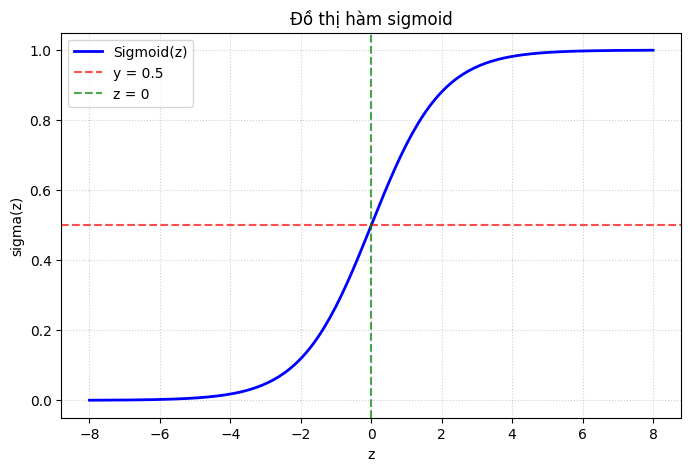

In [ ]:
#Bài tập 2: Vẽ hàm sigmoid
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import numpy as np

def sigmoid(z):
  return 1 / (1 + np.exp(-z))

# Tạo mảng z từ -8 đến 8
z = np.linspace(-8, 8, 200)
s = sigmoid(z)

# Vẽ đồ thị
plt.figure(figsize=(8, 5))
plt.plot(z, s, label="Sigmoid(z)", color="blue", linewidth=2)

# Vẽ đường ngang tại 0.5 và đường dọc tại z=0
plt.axhline(0.5, color="red", linestyle="--", alpha=0.7, label="y = 0.5")
plt.axvline(0, color="green", linestyle="--", alpha=0.7, label="z = 0")

plt.xlabel("z")
plt.ylabel("sigma(z)")
plt.title("Đồ thị hàm sigmoid")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

plt.savefig("sigmoid.png", dpi=150)
plt.show()

In [ ]:
#Bài tập 3: Dự đoán cho một bạn cụ thể
# -*- coding: utf-8 -*-
import pandas as pd
from sklearn.linear_model import LogisticRegression

# Đọc dữ liệu và huấn luyện mô hình một biến (gio_on)
df = pd.read_csv("sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

mo_hinh = LogisticRegression().fit(X, y)

def du_doan(gio):
  df_moi = pd.DataFrame({"gio_on": [gio]})
  xac_suat = mo_hinh.predict_proba(df_moi)[0, 1]
  nhan = mo_hinh.predict(df_moi)[0]
  print(
      f"So gio on: {gio:5.2f} giờ | Xác suất qua môn: {xac_suat:.4f} | Nhãn dự"
      f" đoán: {nhan}"
  )

print("Kết quả dự đoán cho các mốc giờ ôn:")
for g in [3.0, 8.0, 12.89, 18.0, 26.0]:
  du_doan(g)

print()
print(
    "Giải thích: Tại mốc 12.89 giờ, phần tuyến tính z = w*x + b bằng 0,"
    " do đó xác suất sigmoid(0) = 0.5, đúng mốc phân vân 50-50."
)

Kết quả dự đoán cho các mốc giờ ôn:
So gio on:  3.00 giờ | Xác suất qua môn: 0.0201 | Nhãn dự đoán: 0
So gio on:  8.00 giờ | Xác suất qua môn: 0.1276 | Nhãn dự đoán: 0
So gio on: 12.89 giờ | Xác suất qua môn: 0.4996 | Nhãn dự đoán: 0
So gio on: 18.00 giờ | Xác suất qua môn: 0.8814 | Nhãn dự đoán: 1
So gio on: 26.00 giờ | Xác suất qua môn: 0.9942 | Nhãn dự đoán: 1

Giải thích: Tại mốc 12.89 giờ, phần tuyến tính z = w*x + b bằng 0, do đó xác suất sigmoid(0) = 0.5, đúng mốc phân vân 50-50.


In [ ]:
#Bài tập 4: Tự tính bốn thước đo
# -*- coding: utf-8 -*-
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

df = pd.read_csv("sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

# Chia dữ liệu đúng chuẩn theo tài liệu
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)

mo_hinh = LogisticRegression().fit(X_train, y_train)
y_pred = mo_hinh.predict(X_test)

# Lấy 4 giá trị từ ma trận nhầm lẫn (Thứ tự ravel() của sklearn: TN, FP, FN, TP)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
n = len(y_test)

# Tự tính thủ công bằng công thức
accuracy = (tp + tn) / n
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = (
    2 * (precision * recall) / (precision + recall)
    if (precision + recall) > 0
    else 0
)

print(f"Số lượng mẫu kiểm tra: {n}")
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
print(f"Tự tính - Accuracy  = {accuracy:.4f}")
print(f"Tự tính - Precision = {precision:.4f}")
print(f"Tự tính - Recall    = {recall:.4f}")
print(f"Tự tính - F1-score  = {f1:.4f}")

Số lượng mẫu kiểm tra: 30
TN: 9, FP: 3, FN: 1, TP: 17
Tự tính - Accuracy  = 0.8667
Tự tính - Precision = 0.8500
Tự tính - Recall    = 0.9444
Tự tính - F1-score  = 0.8947


In [ ]:
#Bài tập 5: Dò ngưỡng tốt nhất theo F1
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)
mo_hinh = LogisticRegression().fit(X_train, y_train)

# Lấy xác suất dự đoán cho lớp dương (lớp 1)
p = mo_hinh.predict_proba(X_test)[:, 1]

nguongs = np.arange(0.05, 1.0, 0.05)
best_f1 = -1
best_nguong = 0

print(f"{'Ngưỡng':>10} | {'F1-score':>10}")

for nguong in nguongs:
  y_pred = (p >= nguong).astype(int)
  f1 = f1_score(y_test, y_pred, zero_division=0)
  print(f"{nguong:10.2f} | {f1:10.4f}")

  if f1 > best_f1:
    best_f1 = f1
    best_nguong = nguong

print(
    f"Ngưỡng F1-score cao nhất là: {best_nguong:.2f} (với F1 ="
    f" {best_f1:.4f})"
)
print(
    "Nhận xét: Ngưỡng tốt nhất F1 không nhất thiết phải bằng 0.5; tùy"
    " thuộc vào sự phân bố dữ liệu và điểm cân bằng tối ưu giữa precision và"
    " recall trên tập kiểm tra."
)

    Ngưỡng |   F1-score
      0.05 |     0.7826
      0.10 |     0.8182
      0.15 |     0.8182
      0.20 |     0.8571
      0.25 |     0.9000
      0.30 |     0.8947
      0.35 |     0.8947
      0.40 |     0.8947
      0.45 |     0.8947
      0.50 |     0.8947
      0.55 |     0.8889
      0.60 |     0.9412
      0.65 |     0.9412
      0.70 |     0.9091
      0.75 |     0.8750
      0.80 |     0.8387
      0.85 |     0.8000
      0.90 |     0.5600
      0.95 |     0.4348
Ngưỡng F1-score cao nhất là: 0.60 (với F1 = 0.9412)
Nhận xét: Ngưỡng tốt nhất F1 không nhất thiết phải bằng 0.5; tùy thuộc vào sự phân bố dữ liệu và điểm cân bằng tối ưu giữa precision và recall trên tập kiểm tra.


In [ ]:
#Bài tập 6: Đổi lớp dương rồi chấm lại
# -*- coding: utf-8 -*-
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)
mo_hinh = LogisticRegression().fit(X_train, y_train)
y_pred = mo_hinh.predict(X_test)

# Tính cho lớp 1 (Qua môn)
pre_1 = precision_score(y_test, y_pred, pos_label=1)
rec_1 = recall_score(y_test, y_pred, pos_label=1)

# Tính cho lớp 0 (Rớt môn) bằng cách đảo pos_label
pre_0 = precision_score(y_test, y_pred, pos_label=0)
rec_0 = recall_score(y_test, y_pred, pos_label=0)

print(f"Lớp 1 (Qua môn): Precision = {pre_1:.4f} | Recall = {rec_1:.4f}")
print(f"Lớp 0 (Rớt môn): Precision = {pre_0:.4f} | Recall = {rec_0:.4f}")
print(
    "Giải thích: Khi đổi lớp dương từ lớp 1 sang lớp 0, vai trò của các ô trong"
    " ma trận nhầm lẫn thay đổi (TN đổi chỗ cho TP, FP đổi chỗ cho FN). Do đó,"
    " các tỷ lệ tính toán (Precision và Recall) sẽ thay đổi theo góc nhìn của"
    " lớp rớt môn thay vì lớp qua môn, dù dữ liệu và dự đoán không đổi."
)

Lớp 1 (Qua môn): Precision = 0.8500 | Recall = 0.9444
Lớp 0 (Rớt môn): Precision = 0.9000 | Recall = 0.7500
Giải thích: Khi đổi lớp dương từ lớp 1 sang lớp 0, vai trò của các ô trong ma trận nhầm lẫn thay đổi (TN đổi chỗ cho TP, FP đổi chỗ cho FN). Do đó, các tỷ lệ tính toán (Precision và Recall) sẽ thay đổi theo góc nhìn của lớp rớt môn thay vì lớp qua môn, dù dữ liệu và dự đoán không đổi.
